In [3]:
suppressPackageStartupMessages(library(SingleCellExperiment))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(argparse))
suppressPackageStartupMessages(library(Seurat))

#####################
## Define settings ##
#####################
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))



here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/code



In [34]:
args = list()
args$stages <- 'E7.5'
args$sce <- io$rna.sce
args$metadata <- "/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/mapping/sample_metadata_after_mapping.txt.gz"
# args$metadata <- paste0(io$basedir,"/results/rna/doublets/sample_metadata_after_doublets.txt.gz")
args$features <- 3000
args$npcs <- 40
args$n_neighbors = 30
args$min_dist = 0.3
args$test <- FALSE
args$colour_by <- c("celltype.mapped_mnn","sample")
args$vars.to.regress <- c("nFeature_RNA","mitochondrial_percent_RNA")
args$batch_correction <- c("stage")
args$remove_ExE_cells <- FALSE
args$outdir <- paste0(io$basedir,"/results/rna/mapping/test")

In [3]:
dir.create(args$outdir, recursive=TRUE, showWarnings = FALSE)

In [4]:
sample_metadata <- fread(args$metadata) %>%
   .[pass_rnaQC==TRUE & doublet_call==FALSE & stage %in% args$stages]

if (args$remove_ExE_cells) {
  print("Removing ExE cells...")
  sample_metadata <- sample_metadata %>%
    .[!celltype.mapped_mnn%in%c("Visceral_endoderm","ExE_endoderm","ExE_ectoderm","Parietal_endoderm")]
}

In [5]:
head(sample_metadata, 2)

cell,sample,barcode,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,stage,tdTom,idx,tdTom_corr,pass_rnaQC,doublet_score,doublet_call,celltype.mapped_mnn,celltype.score_mnn,stage.mapped_mnn,cellstage.score_mnn,closest.cell_mnn
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<lgl>,<int>,<lgl>,<lgl>,<dbl>,<lgl>,<chr>,<dbl>,<chr>,<dbl>,<chr>
SLX-21143_SITTA2_HTJH3DSX2#AAACCCAAGATGTTCC-1,SLX-21143_SITTA2_HTJH3DSX2,AAACCCAAGATGTTCC-1,4837,53199,1.47,22.87,E8.5,TRUE,1,TRUE,TRUE,0.09,FALSE,Erythroid,1,E8.0,0.56,cell_33109
SLX-21143_SITTA2_HTJH3DSX2#AAACCCATCAGACCTA-1,SLX-21143_SITTA2_HTJH3DSX2,AAACCCATCAGACCTA-1,4973,24165,0.95,19.26,E8.5,TRUE,3,TRUE,TRUE,0.24,FALSE,Mesenchyme,1,E8.75,0.44,ext_cell_141053


In [6]:
###################
## Sanity checks ##
###################

stopifnot(args$colour_by %in% colnames(sample_metadata))
# stopifnot(unique(sample_metadata$celltype.mapped) %in% names(opts$celltype.colors))

 if (length(args$batch_correction)>0) {
   stopifnot(args$batch_correction%in%colnames(sample_metadata))
   if (length(unique(sample_metadata[[args$batch_correction]]))==1) {
     message(sprintf("There is a single level for %s, no batch correction applied",args$batch_correction))
     args$batch_correction <- NULL
   } else {
     library(batchelor)
   }
 }

 if (length(args$vars_to_regress)>0) {
  stopifnot(args$vars_to_regress%in%colnames(sample_metadata))
 }

In [7]:

###############
## Load data ##
###############

# Load RNA expression data as SingleCellExperiment object
sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame


In [8]:
seurat = as.Seurat(sce)

In [9]:
seurat

An object of class Seurat 
29453 features across 44673 samples within 1 assay 
Active assay: RNA (29453 features, 0 variable features)

In [10]:
rm(sce)

In [11]:
################
## Load Atlas ##
################

atlas = readRDS('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/embryo_sce.rds' )

In [16]:
# Rename ensemble IDs to gene names in the atlas
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol")] %>%
  .[symbol!="" & ens_id%in%rownames(atlas)] %>%
  .[!duplicated(symbol)]

atlas <- atlas[rownames(atlas)%in%gene_metadata$ens_id,]
foo <- gene_metadata$symbol; names(foo) <- gene_metadata$ens_id
rownames(atlas) <- foo[rownames(atlas)]

In [17]:
atlas_meta = as.data.table(colData(atlas), keep.rownames=F)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [18]:
atlas = atlas[, as.character(atlas_meta[!stage %in% c('-', 'E6.5', 'E6.75', 'E7.0', 'E7.25'), cell])]

In [20]:
# Lognormalise
atlas <- logNormCounts(atlas,
                      size.factors = as.numeric(sizeFactors(atlas)))

In [21]:
atlas = as.Seurat(atlas)

In [22]:
# Multi core using future - built in to seurat
plan("multicore", workers = 24)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

In [23]:
seurat.list = lapply(X = list(seurat, atlas), FUN = function(x) {
    x <- NormalizeData(x)
    x <- FindVariableFeatures(x, selection.method = "vst", nfeatures = args$features)
})

In [24]:
features <- SelectIntegrationFeatures(object.list = seurat.list)

In [25]:
head(features, 100)

[1] "Actc1"   "Myl7"    "Pf4"     "Myl4"    "Ttn"     "Rbp4"    "Ttr"    
  [8] "Tnnt2"   "Afp"     "Apoa1"   "Spink1"  "Myl3"    "Hbb-bs"  "Hbb-y"  
 [15] "Tnnc1"   "Hba-a1"  "Acta2"   "S100g"   "Apob"    "Apom"    "Myh6"   
 [22] "Myh7"    "Hba-x"   "Hbb-bh1" "Nppa"    "Ankrd1"  "Acta1"   "Aldh1a3"
 [29] "Myl2"    "Apoa2"   "Trh"     "Lyve1"   "Hba-a2"  "Rhox5"   "Col1a1" 
 [36] "Csrp3"   "Nepn"    "Sst"     "Apoe"    "Tagln"   "C1qb"    "Cck"    
 [43] "Spp2"    "Phlda2"  "Barx1"   "Lum"     "Tnni1"   "Apoa4"   "Postn"  
 [50] "Amn"     "Nefm"    "Hspb1"   "Col4a1"  "Etv2"    "Fabp3"   "Lgals2" 
 [57] "Tnni3"   "Dppa3"   "Ctsh"    "Sparc"   "Pyy"     "Sh3bgr"  "Prtn3"  
 [64] "Cubn"    "Crabp1"  "Mt1"     "Tyrobp"  "Mesp1"   "Ripply2" "Fgb"    
 [71] "Nkx2-9"  "Tubb3"   "Trap1a"  "Cldn5"   "Fxyd2"   "Nebl"    "Col1a2" 
 [78] "Col3a1"  "Emcn"    "Myog"    "Clec1b"  "Blvrb"   "Fcer1g"  "Lefty2" 
 [85] "Ccl3"    "Phox2b"  "Ppbp"    "Cdkn1c"  "Rhox9"   "Ctla2a"  "Car4"   
 [92] "Car2"    "Pgam2"   "Plek"    "Dab2"    "Trf"     "Myl9"    "Tcf15"  
 [99] "Tac2"    "Tdgf1"

In [26]:
seurat.list <- lapply(X = seurat.list, FUN = function(x) {
    x <- ScaleData(x, features = features, verbose = FALSE)
    x <- RunPCA(x, features = features, verbose = FALSE)
})

In [27]:
# # Multi core using future - built in to seurat
# plan("multicore", workers = 1)
# options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

In [28]:
anchors <- FindIntegrationAnchors(object.list = seurat.list, anchor.features = features, reduction = "rpca")

Scaling features for provided objects

Computing within dataset neighborhoods

Finding all pairwise anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 67577 anchors



In [ ]:
# this command creates an 'integrated' data assay
seurat.integrated <- IntegrateData(anchorset = anchors)

Merging dataset 1 into 2

Extracting anchors for merged samples



In [ ]:
seurat.integrated

In [ ]:
# specify that we will perform downstream analysis on the corrected data note that the
# original unmodified data still resides in the 'RNA' assay
DefaultAssay(seurat.integrated) <- "integrated"

# Run the standard workflow for visualization and clustering
seurat.integrated <- ScaleData(seurat.integrated, verbose = FALSE)
seurat.integrated <- RunPCA(seurat.integrated, npcs = 30, verbose = FALSE)
seurat.integrated <- RunUMAP(seurat.integrated, reduction = "pca", dims = 1:30)

In [ ]:
saveRDS(seurat.integrated, paste0(args$outdir, '/seurat_test.rds'))

In [5]:
test = readRDS(paste0(args$outdir, '/seurat_test.rds'))

In [11]:
test

An object of class Seurat 
59014 features across 155618 samples within 3 assays 
Active assay: integrated (2000 features, 2000 variable features)
 2 other assays present: RNA, originalexp
 2 dimensional reductions calculated: pca, umap

In [36]:
table(test@meta.data$orig.ident, test@meta.data$stage)

           
             E6.5 E6.75  E7.0 E7.25  E7.5 E7.75  E8.0 E8.25  E8.5
  cell       3484  2075 14749 13537 10994 14493 16681 15935 16909
  ext           0     0     0     0     0     0     0     0 41163
  SLX-21143     0     0     0     0  5598     0     0     0     0

In [28]:
head(colnames(test))

[1] "SLX-21143_SITTD5_HTJH3DSX2#AAACCCAAGAAGCCAC-1"
[2] "SLX-21143_SITTD5_HTJH3DSX2#AAACCCAAGAGAGGTA-1"
[3] "SLX-21143_SITTD5_HTJH3DSX2#AAACCCACACACGGAA-1"
[4] "SLX-21143_SITTD5_HTJH3DSX2#AAACCCATCAAGTAAG-1"
[5] "SLX-21143_SITTD5_HTJH3DSX2#AAACGAAAGATACCAA-1"
[6] "SLX-21143_SITTD5_HTJH3DSX2#AAACGAACAAATCAAG-1"

In [31]:
tail(grep('SLX', colnames(test)))

[1] 5593 5594 5595 5596 5597 5598

In [32]:
tail(test@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,sample,barcode,mitochondrial_percent_RNA,ribosomal_percent_RNA,stage,tdTom,idx,⋯,phase,r_louvain_clus,r_louvain_subclus,louvain,leiden,celltype_PijuanSala2019,celltype_PijuanSala2019_E85mapped,celltype_PijuanSala2019_E85mapped_WOTdescendant,celltype_extended_atlas,sizeFactor
,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<lgl>,<int>,⋯,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>
ext_cell_308614,ext,NA,NA,97,NA,NA,NA,E8.5,NA,NA,⋯,G2M,19,1,9,4,New cells,Endothelium,Endothelium,YS endothelium,2.492177
ext_cell_308615,ext,NA,NA,97,NA,NA,NA,E8.5,NA,NA,⋯,G2M,2,4,6,0,New cells,Erythroid3,Erythroid3,Erythroid,1.245165
ext_cell_308616,ext,NA,NA,97,NA,NA,NA,E8.5,NA,NA,⋯,G2M,10,5,8,28,New cells,ExE endoderm,ExE endoderm,ExE endoderm,3.347149
ext_cell_308617,ext,NA,NA,97,NA,NA,NA,E8.5,NA,NA,⋯,G2M,24,3,2,29,New cells,Mesenchyme,Mesenchyme,Mesenchyme,1.166690
ext_cell_308618,ext,NA,NA,97,NA,NA,NA,E8.5,NA,NA,⋯,S,2,7,6,9,New cells,Erythroid2,Erythroid2,Erythroid,1.471676
ext_cell_308619,ext,NA,NA,97,NA,NA,NA,E8.5,NA,NA,⋯,G2M,2,9,6,48,New cells,Erythroid3,Erythroid3,Erythroid,1.037187


In [ ]:
test@meta.data$dataset = ifelse(celltype_PijuanSala2019=='new_cell')

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



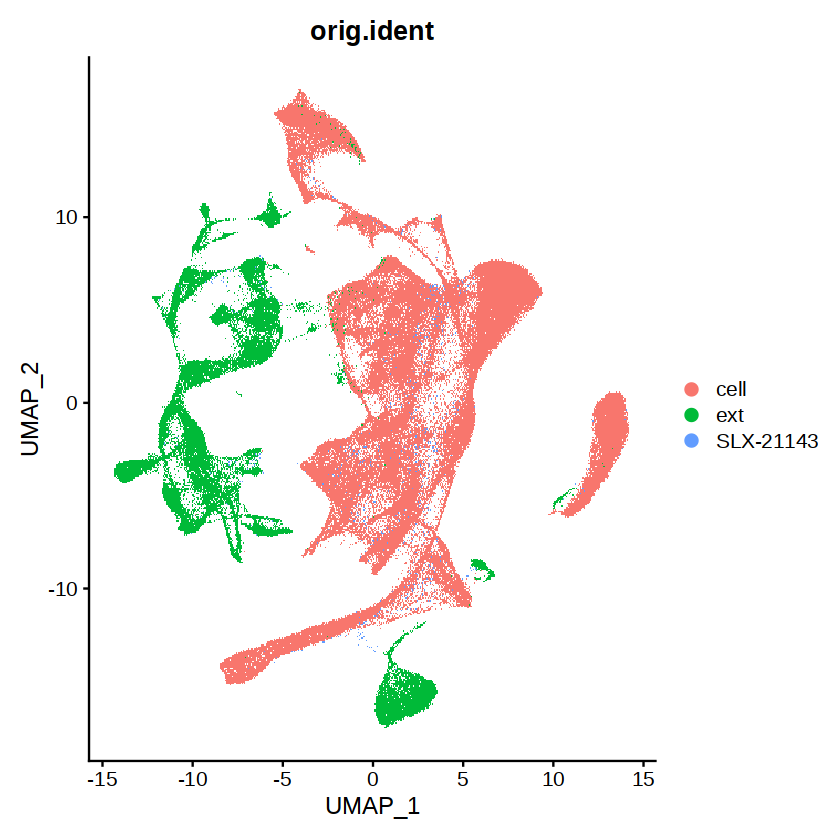

In [33]:
DimPlot(test, reduction = "umap", group.by='orig.ident')

In [ ]:
umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell"))